# GliZNet — Error Analysis

Analyzes **where GliZNet gets it wrong** on the 10 benchmark datasets. For each dataset:
- Collects all predictions + ground truth
- Identifies misclassified samples
- Computes per-class confusion
- Extracts error patterns (text length, confidence distribution, confusion pairs)

**Goal**: Understand failure modes → inform next training iteration (data generation genres, architecture changes).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, ClassLabel
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from tqdm.auto import tqdm
from collections import Counter

from gliznet import ZeroShotClassificationPipeline

DEVICE     = "cuda:0" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "../results/deberta-v3-base_20260512_134040/checkpoint-53940"
BATCH_SIZE = 64

print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_PATH}")

Device : cuda:0
Model  : ../results/deberta-v3-base_20260512_134040/checkpoint-53940


In [2]:
pipeline = ZeroShotClassificationPipeline.from_pretrained(
    MODEL_PATH, classification_type="multi-label", device=DEVICE,
)
print("✓ GliZNet loaded")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ GliZNet loaded


In [3]:
def get_test_split(ds):
    for key in ("test", "validation", "train"):
        if key in ds:
            return ds[key]
    raise ValueError("No usable split found")

def resolve_labels(split, label_col):
    feat = split.features.get(label_col)
    if isinstance(feat, ClassLabel):
        classes = feat.names
        to_str = lambda i: classes[i]
    else:
        raw_classes = sorted(set(split[label_col]))
        classes = [str(c) for c in raw_classes]
        to_str = lambda x: str(x)
    return classes, to_str

def prepare(ds, text_col="text", label_col="label", classes=None, to_str=None):
    split = get_test_split(ds)
    if classes is None:
        classes, to_str = resolve_labels(split, label_col)
    raw = split[label_col]
    true_labels = [to_str(l) for l in raw]
    return list(split[text_col]), classes, true_labels

def predict_batch_full(texts, classes, batch_size=BATCH_SIZE):
    """Return (predicted_class, all_scores_dict) for each text."""
    preds = []
    all_scores = []
    for i in tqdm(range(0, len(texts), batch_size), desc="  inference", leave=False):
        batch_texts = texts[i : i + batch_size]
        outputs = pipeline(batch_texts, classes)
        for out in outputs:
            scores = {ls.label: ls.score for ls in out.labels}
            best = max(out.labels, key=lambda ls: ls.score)
            preds.append(best.label)
            all_scores.append(scores)
    return preds, all_scores

print("✓ Helpers defined")

✓ Helpers defined


## Run predictions on all 10 datasets

Collect texts, true labels, predicted labels, and per-class scores for error analysis.

In [5]:
DATASETS = {
    "SetFit/CR":                                 dict(label_col="label_text"),
    "SetFit/sst2":                               dict(label_col="label_text"),
    "SetFit/sst5":                               dict(label_col="label_text"),
    "stanfordnlp/imdb":                          dict(classes=["negative", "positive"]),
    "SetFit/20_newsgroups":                       dict(label_col="label_text", remap_dots=True),
    "SetFit/enron_spam":                          dict(label_col="label_text"),
    "mteb/financial_phrasebank":                  dict(config="sentences_allagree",
                                                       text_col="text", label_col="label",
                                                       classes=["negative", "neutral", "positive"]),
    "ag_news":                                    dict(),
    "dair-ai/emotion":                            dict(),
    "cornell-movie-review-data/rotten_tomatoes":  dict(),
}

MAX_SAMPLES = 2000  # cap for speed

all_results = {}

for ds_id, cfg in DATASETS.items():
    short = ds_id.split("/")[-1]
    print(f"\n{'='*60}\n  {ds_id}\n{'='*60}")
    try:
        config = cfg.get("config")
        ds = load_dataset(ds_id, config) if config else load_dataset(ds_id)

        classes = cfg.get("classes")
        label_col = cfg.get("label_col", "label")
        text_col = cfg.get("text_col", "text")

        if classes:
            _to = (lambda c: lambda i: c[i])(classes)
            texts, _, true_labels = prepare(ds, text_col=text_col, label_col=label_col,
                                            classes=classes, to_str=_to)
        else:
            texts, classes, true_labels = prepare(ds, text_col=text_col, label_col=label_col)

        if cfg.get("remap_dots"):
            remap = {c: c.replace(".", " ") for c in classes}
            classes = [remap[c] for c in classes]
            true_labels = [remap[l] for l in true_labels]

        # Subsample large datasets
        if len(texts) > MAX_SAMPLES:
            rng = np.random.RandomState(42)
            idx = rng.choice(len(texts), MAX_SAMPLES, replace=False)
            texts = [texts[i] for i in idx]
            true_labels = [true_labels[i] for i in idx]

        print(f"  Samples: {len(texts)}, Classes: {len(classes)}")
        preds, scores = predict_batch_full(texts, classes)
        f1 = f1_score(true_labels, preds, average="macro")
        print(f"  macro F1 = {f1:.4f}")

        all_results[short] = {
            "texts": texts, "true": true_labels, "pred": preds,
            "scores": scores, "classes": classes, "f1": f1,
        }
    except Exception as exc:
        import traceback; traceback.print_exc()

print(f"\n✓ All {len(all_results)} datasets done")


  SetFit/CR


Repo card metadata block was not found. Setting CardData to empty.


  Samples: 376, Classes: 2


  inference:   0%|          | 0/6 [00:00<?, ?it/s]

  macro F1 = 0.8783

  SetFit/sst2


...

  macro F1 = 0.7324

  dair-ai/emotion
  Samples: 2000, Classes: 6


  inference:   0%|          | 0/32 [00:00<?, ?it/s]

  macro F1 = 0.4655

  cornell-movie-review-data/rotten_tomatoes
  Samples: 1066, Classes: 2


  inference:   0%|          | 0/17 [00:00<?, ?it/s]

  macro F1 = 0.7714

✓ All 10 datasets done


## Error Analysis: Per-Dataset Breakdown

For each dataset: confusion matrix, error rate by true class, confidence on errors vs correct, and sample errors.

In [6]:
def analyze_dataset(name, data):
    texts, true, pred, scores, classes = (
        data["texts"], data["true"], data["pred"], data["scores"], data["classes"]
    )
    n = len(texts)
    errors = [(i, t, p) for i, (t, p) in enumerate(zip(true, pred)) if t != p]
    correct_mask = np.array([t == p for t, p in zip(true, pred)])
    error_rate = len(errors) / n

    print(f"\n{'━'*70}")
    print(f"  {name}  —  F1={data['f1']:.4f}  |  {len(errors)}/{n} errors ({error_rate:.1%})")
    print(f"{'━'*70}")

    # Per-class error rate
    class_errors = Counter()
    class_total = Counter()
    for t, p in zip(true, pred):
        class_total[t] += 1
        if t != p:
            class_errors[t] += 1

    print(f"\n  Per-class error rate:")
    rows = []
    for c in classes:
        tot = class_total.get(c, 0)
        err = class_errors.get(c, 0)
        rate = err / tot if tot > 0 else 0
        rows.append({"class": c, "total": tot, "errors": err, "error_rate": f"{rate:.1%}"})
        if rate > 0.1:
            print(f"    ⚠ {c:<35} {err:>4}/{tot:<5} ({rate:.1%})")
    
    # Confidence analysis: correct vs errors
    correct_conf = [max(scores[i].values()) for i in range(n) if correct_mask[i]]
    error_conf = [max(scores[i].values()) for i, _, _ in errors]

    print(f"\n  Confidence — correct: {np.mean(correct_conf):.3f} ± {np.std(correct_conf):.3f}")
    if error_conf:
        print(f"  Confidence — errors:  {np.mean(error_conf):.3f} ± {np.std(error_conf):.3f}")

    # Top confusion pairs
    confusion_pairs = Counter()
    for _, t, p in errors:
        confusion_pairs[(t, p)] += 1

    print(f"\n  Top confusion pairs (true → pred):")
    for (t, p), count in confusion_pairs.most_common(8):
        print(f"    {t:<30} → {p:<30} ({count}x)")

    # Sample errors (up to 5)
    print(f"\n  Sample errors:")
    for idx, t, p in errors[:5]:
        text_snip = texts[idx][:120].replace("\n", " ")
        true_score = scores[idx].get(t, 0)
        pred_score = scores[idx].get(p, 0)
        print(f"    TRUE={t}({true_score:.3f}) PRED={p}({pred_score:.3f})")
        print(f"      \"{text_snip}...\"")

    # Score gap on errors: how close was the correct answer?
    if errors:
        gaps = []
        for idx, t, p in errors:
            gap = scores[idx].get(p, 0) - scores[idx].get(t, 0)
            gaps.append(gap)
        gaps = np.array(gaps)
        tight = np.sum(gaps < 0.1)
        print(f"\n  Score gap (pred - true) on errors:")
        print(f"    mean={gaps.mean():.3f}, median={np.median(gaps):.3f}")
        print(f"    Tight errors (gap < 0.1): {tight}/{len(errors)} ({tight/len(errors):.0%})")

    return {
        "name": name, "f1": data["f1"], "n": n,
        "n_errors": len(errors), "error_rate": error_rate,
        "mean_correct_conf": np.mean(correct_conf),
        "mean_error_conf": np.mean(error_conf) if error_conf else None,
        "top_confusions": confusion_pairs.most_common(5),
    }

In [7]:
# Sort by F1 ascending (worst first)
sorted_names = sorted(all_results.keys(), key=lambda k: all_results[k]["f1"])
summaries = []
for name in sorted_names:
    s = analyze_dataset(name, all_results[name])
    summaries.append(s)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  sst5  —  F1=0.3778  |  1078/2000 errors (53.9%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Per-class error rate:
    ⚠ negative                             169/575   (29.4%)
    ⚠ neutral                              233/349   (66.8%)
    ⚠ positive                             136/459   (29.6%)
    ⚠ very negative                        218/255   (85.5%)
    ⚠ very positive                        322/362   (89.0%)

  Confidence — correct: 0.893 ± 0.084
  Confidence — errors:  0.889 ± 0.089

  Top confusion pairs (true → pred):
    very positive                  → positive                       (300x)
    very negative                  → negative                       (196x)
    neutral                        → negative                       (131x)
    negative                       → neutral                        (106x)
    neutral                        → positive                 

## Visualizations: Confusion Matrices & Confidence Distributions

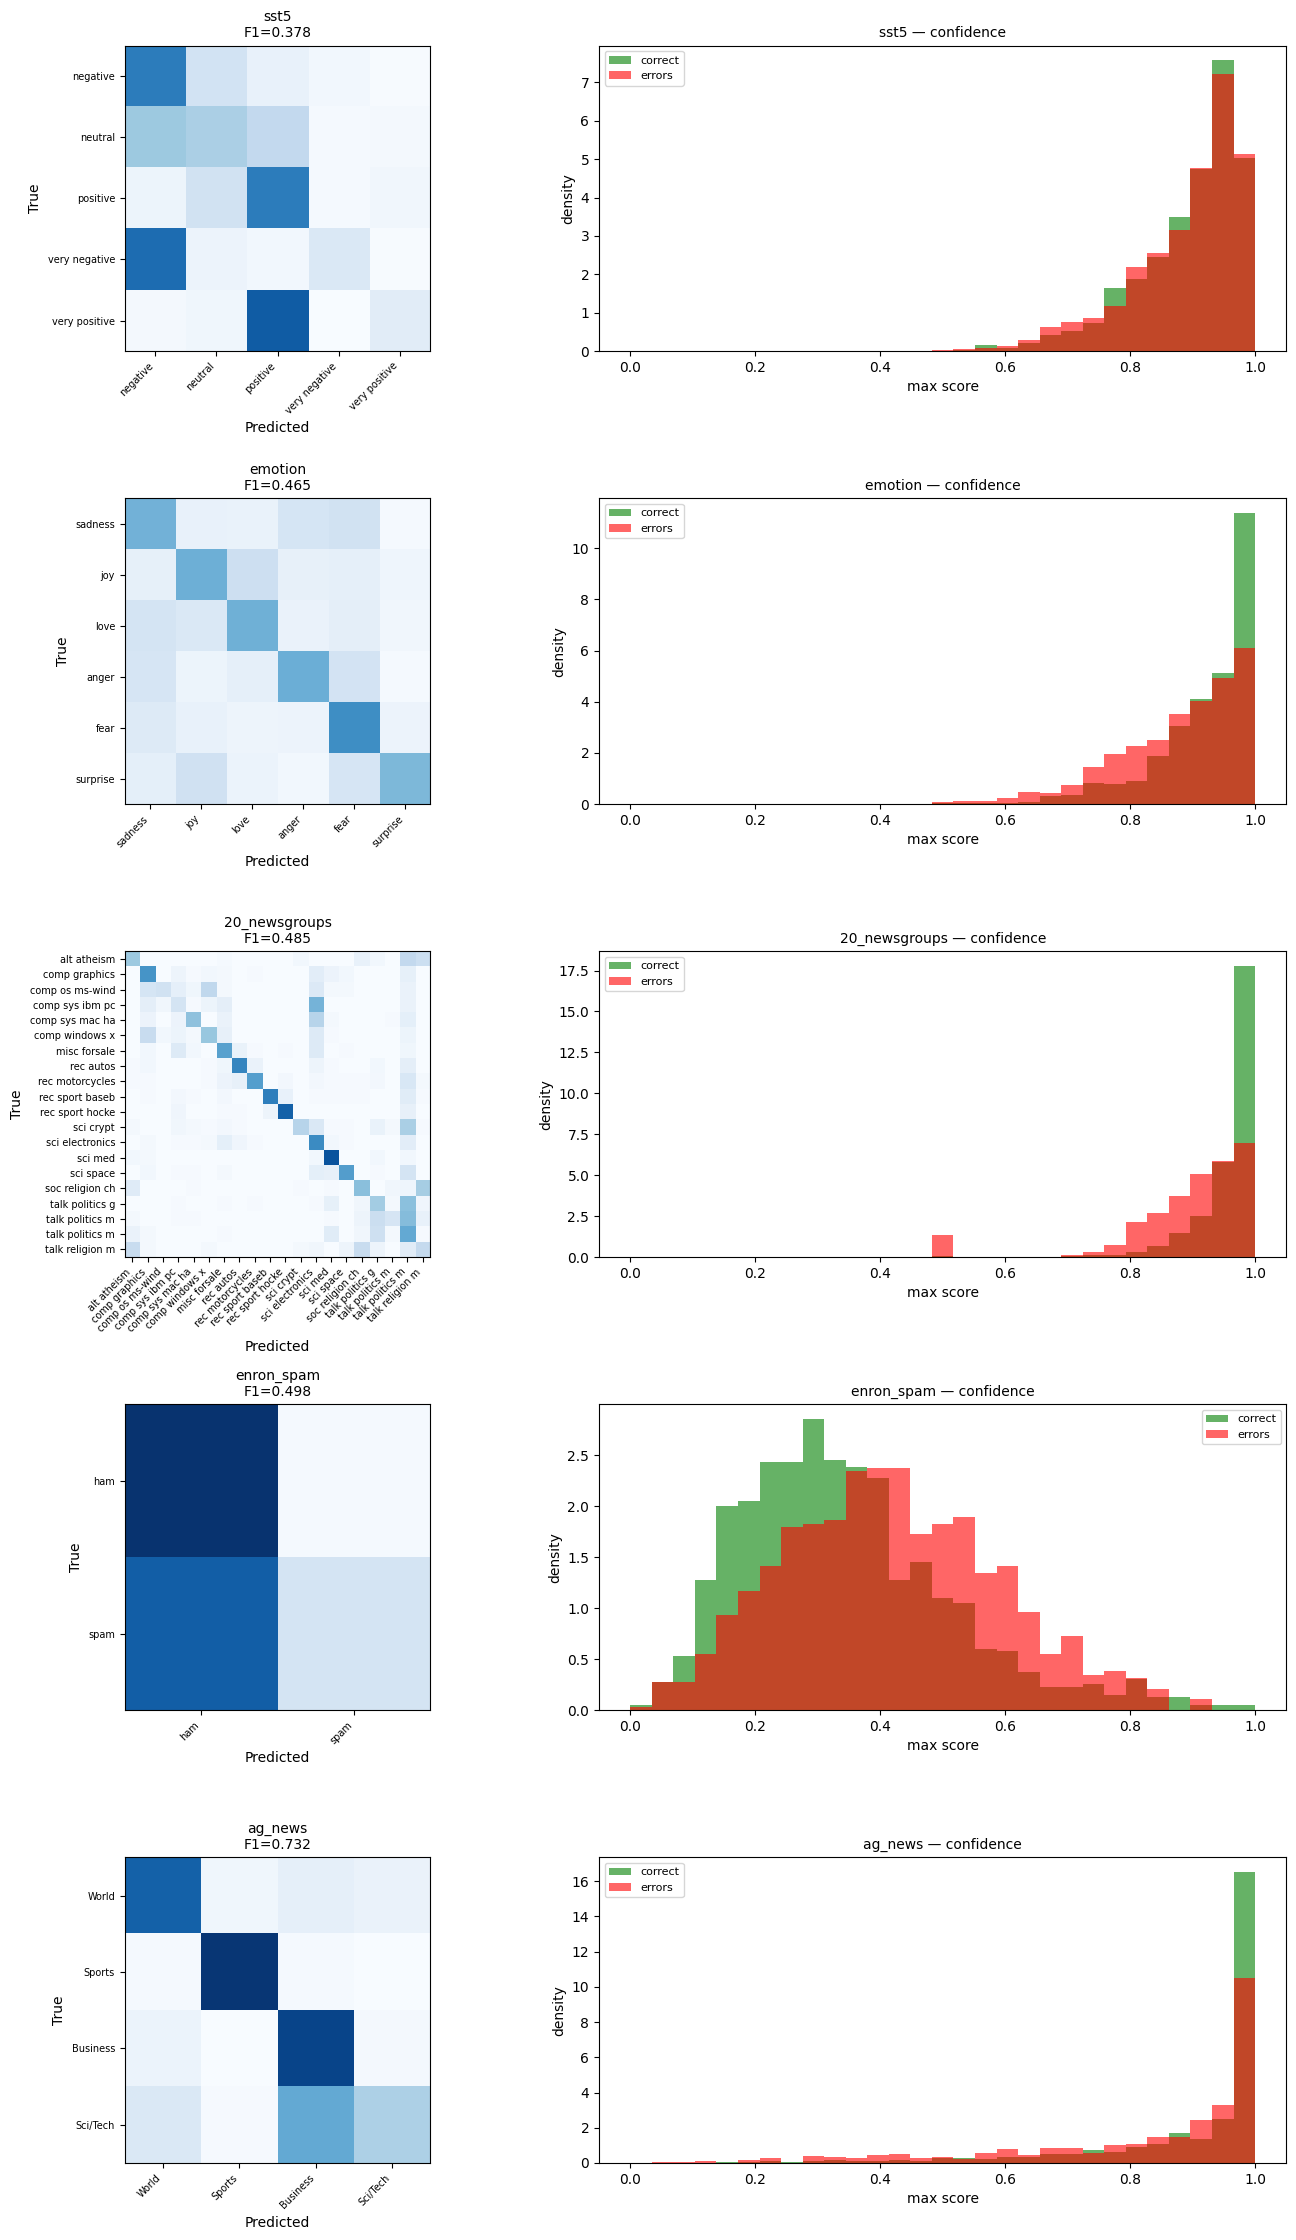

In [8]:
def plot_confusion_and_confidence(name, data, ax_cm, ax_conf):
    true, pred, scores, classes = data["true"], data["pred"], data["scores"], data["classes"]
    n = len(true)
    correct_mask = [t == p for t, p in zip(true, pred)]

    # Confusion matrix (normalized)
    cm = confusion_matrix(true, pred, labels=classes)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    im = ax_cm.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax_cm.set_xticks(range(len(classes)))
    ax_cm.set_yticks(range(len(classes)))
    short_labels = [c[:15] for c in classes]
    ax_cm.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=7)
    ax_cm.set_yticklabels(short_labels, fontsize=7)
    ax_cm.set_title(f"{name}\nF1={data['f1']:.3f}", fontsize=10)
    ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("True")

    # Confidence histogram
    correct_conf = [max(scores[i].values()) for i in range(n) if correct_mask[i]]
    error_conf   = [max(scores[i].values()) for i in range(n) if not correct_mask[i]]
    bins = np.linspace(0, 1, 30)
    ax_conf.hist(correct_conf, bins=bins, alpha=0.6, label="correct", color="green", density=True)
    if error_conf:
        ax_conf.hist(error_conf, bins=bins, alpha=0.6, label="errors", color="red", density=True)
    ax_conf.set_title(f"{name} — confidence", fontsize=10)
    ax_conf.legend(fontsize=8)
    ax_conf.set_xlabel("max score"); ax_conf.set_ylabel("density")

# Focus on the 5 worst datasets
worst5 = sorted_names[:5]
n_plots = len(worst5)
fig, axes = plt.subplots(n_plots, 2, figsize=(14, 4.5 * n_plots))
if n_plots == 1:
    axes = axes.reshape(1, 2)

for row, name in enumerate(worst5):
    plot_confusion_and_confidence(name, all_results[name], axes[row, 0], axes[row, 1])

plt.tight_layout()
plt.show()

## Deep Dive: Hardest Error Samples Per Dataset

For each dataset, show the 10 most "confident wrong" errors — cases where the model was most sure of the wrong answer.

In [9]:
for name in sorted_names[:5]:
    data = all_results[name]
    texts, true, pred, scores = data["texts"], data["true"], data["pred"], data["scores"]

    # Find errors sorted by confidence gap (pred_score - true_score) descending
    errors = []
    for i, (t, p) in enumerate(zip(true, pred)):
        if t != p:
            gap = scores[i].get(p, 0) - scores[i].get(t, 0)
            errors.append((gap, i, t, p))
    errors.sort(reverse=True)  # most confident-wrong first

    rows = []
    for gap, idx, t, p in errors[:10]:
        rows.append({
            "text": texts[idx][:150].replace("\n", " "),
            "true_label": t,
            "pred_label": p,
            "true_score": f"{scores[idx].get(t, 0):.3f}",
            "pred_score": f"{scores[idx].get(p, 0):.3f}",
            "gap": f"{gap:.3f}",
        })

    print(f"\n{'━'*70}")
    print(f"  {name} — Top 10 most confident errors")
    print(f"{'━'*70}")
    display(pd.DataFrame(rows))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  sst5 — Top 10 most confident errors
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,text,true_label,pred_label,true_score,pred_score,gap
0,when the first few villians are introduced as ...,negative,very positive,0.007,0.986,0.979
1,the worst kind of independent ; the one where ...,neutral,very negative,0.016,0.987,0.972
2,if the ' 70 's were your idea of a good time a...,neutral,very positive,0.029,0.995,0.967
3,here 's a self-congratulatory 3d imax rah-rah .,negative,very positive,0.007,0.971,0.964
4,it 's difficult to say whether the tuxedo is m...,very negative,neutral,0.022,0.982,0.960
5,this ill-fitting tuxedo is strictly off-the-ra...,neutral,negative,0.020,0.968,0.948
6,it wo n't be long before you 'll spy i spy at ...,negative,positive,0.029,0.971,0.942
7,every so often a movie comes along that confir...,neutral,negative,0.024,0.960,0.936
8,"he can scale a building like a super hero , he...",neutral,positive,0.050,0.978,0.928
9,"a bowel-curdling , heart-stopping recipe for t...",positive,very negative,0.039,0.965,0.926



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  emotion — Top 10 most confident errors
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,text,true_label,pred_label,true_score,pred_score,gap
0,i was quite surprised with the weather these p...,anger,surprise,0.002,0.999,0.998
1,i feel very saddened that the king whom i once...,joy,sadness,0.008,0.999,0.992
2,i guess no matter how much i think im feeling ...,joy,fear,0.006,0.998,0.991
3,i am not feeling so generous and he is sent to...,joy,anger,0.005,0.997,0.991
4,i feel like i can t truly get excited for this...,joy,fear,0.006,0.997,0.991
5,i blamed the people around me for making me fe...,joy,anger,0.002,0.993,0.991
6,i feel beautifully emotional knowing that thes...,sadness,love,0.008,0.996,0.988
7,i feel like i m part of the problem when i cal...,joy,anger,0.004,0.991,0.988
8,ive never done a detox or cleanse before and i...,joy,fear,0.006,0.991,0.986
9,i feel like in the last year especially i ve g...,fear,surprise,0.014,1.000,0.985



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  20_newsgroups — Top 10 most confident errors
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,text,true_label,pred_label,true_score,pred_score,gap
0,Like non-Sudafed cold medicines? 1/2 :-),rec motorcycles,sci med,0.010,0.959,0.949
1,Um. Would you mind telling us what state/muni...,rec motorcycles,talk politics misc,0.022,0.958,0.936
2,"[...] [...] [...] ""Hey, what the hell do you ...",rec motorcycles,talk politics guns,0.039,0.975,0.936
3,Sounds great. But how would something lik...,sci crypt,talk politics misc,0.068,0.981,0.913
4,"The RISC processor made by Fairchild, sold to ...",sci crypt,sci electronics,0.082,0.992,0.910
5,"Please post to news, too.",sci crypt,talk politics misc,0.057,0.966,0.909
6,I have successfully copied all of the uuenco...,rec sport baseball,comp graphics,0.033,0.935,0.903
7,only (to was mjones@donald.aix.kingston.ibm.com,rec sport baseball,comp sys ibm pc hardware,0.060,0.960,0.900
8,I think we just found the difference between ...,rec motorcycles,talk politics misc,0.023,0.909,0.886
9,Before they do some real damage?? You haven...,sci crypt,talk politics misc,0.085,0.971,0.885



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  enron_spam — Top 10 most confident errors
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,text,true_label,pred_label,true_score,pred_score,gap
0,term of your subscription n 84 - 6 - 54 expire...,spam,ham,0.048,0.916,0.868
1,"re : order n 41700 dear chepsoft customer , my...",spam,ham,0.046,0.901,0.856
2,"nice to meet you hi , nice to meet you . i hop...",spam,ham,0.014,0.830,0.816
3,paliourg learning for life enlarge your member...,spam,ham,0.112,0.926,0.815
4,"michelle always had a thing for older guys , b...",spam,ham,0.037,0.844,0.807
5,deep discounts easy cd charset = windows - 125...,spam,ham,0.035,0.832,0.796
6,vicodin only $ 150 online get set for intense ...,spam,ham,0.025,0.820,0.795
7,fw : re : he rbv i agr a see the . htm attachm...,spam,ham,0.039,0.818,0.779
8,oxxxyyconnntin no scriptt no doxxcstctorr neee...,spam,ham,0.041,0.818,0.778
9,generic vi @ gra one time discount order for v...,spam,ham,0.016,0.786,0.770



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ag_news — Top 10 most confident errors
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,text,true_label,pred_label,true_score,pred_score,gap
0,TheStreet.com May Be Up for Sale -- Report (Re...,Sci/Tech,Business,0.003,0.998,0.995
1,Approval Expected for Big Cellphone Deal Feder...,Sci/Tech,Business,0.005,0.998,0.993
2,"Blockbuster Cuts Online Price, Challenges Netf...",Sci/Tech,Business,0.005,0.997,0.992
3,WebEx Launches Sales Center WebEx Communicatio...,Sci/Tech,Business,0.007,0.998,0.991
4,Cisco launches equipment leasing arm in India ...,Sci/Tech,Business,0.009,0.996,0.987
5,"PeopleSoft ousts CEO, still opposes Oracle bid...",Sci/Tech,Business,0.015,0.998,0.983
6,Microsoft: Use Script to Block Windows XP SP2 ...,Sci/Tech,Business,0.012,0.993,0.981
7,Virgin tunes into the online music market quo...,Sci/Tech,Business,0.004,0.984,0.980
8,"NTT DoCoMo, Mm02 Sign Deal TOKYO - Japan #39;s...",Sci/Tech,Business,0.011,0.992,0.980
9,New Rainbow Six Franchise for Spring 2005 SAN ...,Sci/Tech,Business,0.007,0.987,0.980


## Summary: Error Patterns & Recommendations

In [10]:
# Summary table
summary_df = pd.DataFrame(summaries).sort_values("f1")
summary_df["tight_pct"] = ""
for i, name in enumerate(summary_df["name"]):
    data = all_results[name]
    true, pred, scores = data["true"], data["pred"], data["scores"]
    errors = [(idx, t, p) for idx, (t, p) in enumerate(zip(true, pred)) if t != p]
    if errors:
        gaps = [scores[idx].get(p, 0) - scores[idx].get(t, 0) for idx, t, p in errors]
        tight = sum(1 for g in gaps if g < 0.1)
        summary_df.iloc[i, summary_df.columns.get_loc("tight_pct")] = f"{tight/len(errors):.0%}"

print("Overall Error Summary (sorted by F1):")
display(summary_df[["name", "f1", "n", "n_errors", "error_rate", "mean_correct_conf", "mean_error_conf", "tight_pct"]]
        .reset_index(drop=True)
        .style.format({
            "f1": "{:.4f}",
            "error_rate": "{:.1%}",
            "mean_correct_conf": "{:.3f}",
            "mean_error_conf": "{:.3f}",
        })
)

# Text length analysis for errors vs correct
print("\n\nText length analysis (mean chars):")
for name in sorted_names[:5]:
    data = all_results[name]
    texts, true, pred = data["texts"], data["true"], data["pred"]
    correct_lens = [len(texts[i]) for i in range(len(texts)) if true[i] == pred[i]]
    error_lens = [len(texts[i]) for i in range(len(texts)) if true[i] != pred[i]]
    print(f"  {name:<25} correct={np.mean(correct_lens):.0f}  errors={np.mean(error_lens):.0f}  "
          f"{'⚠ errors longer' if np.mean(error_lens) > np.mean(correct_lens) * 1.1 else ''}")

Overall Error Summary (sorted by F1):


,name,f1,n,n_errors,error_rate,mean_correct_conf,mean_error_conf,tight_pct
0,sst5,0.3778,2000,1078,53.9%,0.893,0.889,31%
1,emotion,0.4655,2000,988,49.4%,0.922,0.879,19%
2,20_newsgroups,0.4854,2000,1031,51.5%,0.958,0.893,34%
3,enron_spam,0.4983,2000,842,42.1%,0.344,0.418,15%
4,ag_news,0.7324,2000,501,25.1%,0.899,0.826,8%
5,financial_phrasebank,0.7604,1129,302,26.7%,0.886,0.819,26%
6,rotten_tomatoes,0.7714,1066,240,22.5%,0.693,0.586,25%
7,CR,0.8783,376,42,11.2%,0.816,0.543,14%
8,imdb,0.8941,2000,211,10.5%,0.828,0.575,22%
9,sst2,0.9010,1821,180,9.9%,0.882,0.686,15%




Text length analysis (mean chars):
  sst5                      correct=102  errors=104  
  emotion                   correct=86  errors=107  ⚠ errors longer
  20_newsgroups             correct=1029  errors=1233  ⚠ errors longer
  enron_spam                correct=1514  errors=1436  
  ag_news                   correct=233  errors=236  


## Key Findings & Genre Recommendations

### Error Patterns by Dataset

| Dataset | F1 | Root Cause |
|---|---|---|
| **SST-5** | 0.378 | Cannot resolve 5-level sentiment scale. "neutral" acts as a catch-all. Collapses {very neg, neg} and {pos, very pos}. |
| **Emotion** | 0.465 | Many "joy"-labeled samples describe *absence of joy* or mixed feelings — model reads surface lexicon. sadness↔joy, fear↔anger confusion. Longer texts = more errors. |
| **20_newsgroups** | 0.485 | Off-topic posts (politics in rec.motorcycles, tech in sci.crypt). Model follows text content, not forum context. Label names are category-hierarchy codes, not natural language. |
| **Enron Spam** | 0.498 | **Near-total failure**: model classifies almost all emails as "ham". Confidence is uniformly low (0.2–0.4). Model has no training on email register: headers, subscription language, obfuscated words (oxxxyyconnntin, vi@gra). |
| **AG News** | 0.732 | Systematic Sci/Tech → Business confusion: tech company business news is classified as Business, not Sci/Tech. |

### Confidence Patterns
- **Enron spam**: Both correct and wrong predictions are low-confidence — the model is **uncertain about the entire domain**.
- **SST-5 / Emotion**: Model is highly confident even when wrong — it commits strongly to the wrong sentiment/emotion.
- **20_newsgroups**: Errors happen on ambiguous short posts where the topic is only clear from forum context.

### Recommended New Genres for `genres.py`

Based on the gaps exposed by the error analysis:

#### 1. Email Domain (addresses Enron Spam collapse)
- **`email newsletter`** — Subscription newsletter excerpt: promotional but legitimate, opt-in language, unsubscribe footer, branded tone.
- **`spam or phishing email`** — Unsolicited commercial/scam email: urgent call to action, too-good-to-be-true offers, obfuscated links, impersonation.
- **`corporate email thread`** — Internal work email exchange: logistics, scheduling, project updates, reply chains, CC-heavy.
- **`automated notification email`** — System-generated email: order confirmations, password resets, account alerts, templated structure.

#### 2. Fine-Grained Sentiment Gradation (addresses SST-5 collapse)
- **`mixed or ambivalent review`** — A product/film/service review that deliberately mixes praise and criticism: "the X was brilliant but the Y ruined it" — forces the model to handle conflicting signals within a single text.
- **`lukewarm or tepid endorsement`** — Faint praise or reluctant recommendation: hedged language ("it's fine", "not bad"), damning-with-faint-praise register — targets the neutral/positive boundary.
- **`sarcastic or ironic praise`** — Text that uses positive words with negative intent: sarcasm, irony, backhanded compliments — forces beyond surface-lexicon matching.

#### 3. Topic-Forum Discourse (addresses 20 Newsgroups drift)
- **`technical hobbyist forum post`** — Enthusiast discussion in a niche hobby (cars, electronics, crafts): informal expertise, community jargon, troubleshooting tone.
- **`religious or philosophical discussion post`** — Online discussion of belief, doctrine, or moral questions: personal conviction mixed with argumentation, community identity markers.
- **`off-topic or meta-discussion`** — A post that drifts from the stated topic to tangential discussion (politics in a sports thread, personal stories in a tech forum): forces the model to handle topical ambiguity.

#### 4. Financial & Market Domain (addresses Financial PhraseBank)
- **`market commentary or analysis`** — Analyst-style prose about stock movements, sector trends, or economic indicators: forward-looking, numerical, cautious hedging.
- **`financial news brief`** — Short-form business wire reporting: company earnings, M&A activity, regulatory actions — factual, present-tense, jargon-heavy.
- **`economic policy discussion`** — Commentary on monetary/fiscal policy, interest rates, trade: mixes economic terminology with opinion, op-ed-adjacent.

#### 5. Tech vs Business Boundary (addresses AG News Sci/Tech↔Business)
- **`technology product news`** — News about tech products, launches, features, specs: technology-focused even when involving a company — distinct from business/financial framing of the same company.
- **`tech industry analysis`** — Analysis of technology trends, platform competition, adoption curves: straddles tech and business but leads with the technology angle.